# Diamonds Price Prediction - Polynomial Regression Model

## 1. Imports 

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures , StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_squared_error , r2_score 
from sklearn.pipeline import Pipeline

In [4]:
df = pd.read_excel(
    "diamonds.xlsx", 
    sheet_name="diamonds"
)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53794 entries, 0 to 53793
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Carat         53794 non-null  float64
 1   Cut           53794 non-null  object 
 2   Cut Rank      53794 non-null  int64  
 3   Color         53794 non-null  object 
 4   Color Rank    53794 non-null  int64  
 5   Clarity       53794 non-null  object 
 6   Clarity Rank  53794 non-null  int64  
 7   Depth         53794 non-null  float64
 8   Table         53794 non-null  float64
 9   Price         53794 non-null  int64  
 10  Length (x)    53794 non-null  float64
 11  Width (y)     53794 non-null  float64
 12  Height (z)    53794 non-null  float64
 13  Volume_mm3    53794 non-null  float64
dtypes: float64(7), int64(4), object(3)
memory usage: 5.7+ MB


In [6]:
features = [
    "Carat",
    "Volume_mm3",
    "Cut Rank",
    "Color Rank",
    "Clarity Rank",
    "Depth",
    "Table"
]

In [7]:
x = df[features]
y = df["Price"]

In [8]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
degrees = [1,2,3,4,5]

for degree in degrees:
    
    traning_model = Pipeline([
        ("poly", PolynomialFeatures(
            degree=degree , 
            include_bias=False
        )),
        ("scaler",StandardScaler()),
        ("model",LinearRegression())  
    ])
    
    traning_model.fit(x_train, y_train)
    y_valdiation = traning_model.predict(x_test)
    
    mse = mean_squared_error(
        y_test, 
        y_valdiation
    )
    print(f"Degree {degree}: Validation MSE = {mse}")

Degree 1: Validation MSE = 1448487.7069686987
Degree 2: Validation MSE = 762880.1892544039
Degree 3: Validation MSE = 592743.0515310303
Degree 4: Validation MSE = 457591955.14413506
Degree 5: Validation MSE = 1174143654476.2456


In [11]:
model = Pipeline([
    ("Poly", PolynomialFeatures(
        degree=3,
        include_bias= False
    )),
    ("Scaler", StandardScaler()),
    ("Model", LinearRegression())
])


In [12]:
model.fit(x_test, y_test)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('Poly', ...), ('Scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",3
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [14]:
y_hat = model.predict(x_test)

print("\nPredictions:")
print(y_hat)

print("\nActual:")
print(y_test.values)


Predictions:
[ 1342.91619861  3312.5506954   2031.57069623 ...   843.45958229
 14288.01851124   963.78013976]

Actual:
[ 1435  3584  1851 ...   912 15002  1071]


In [15]:
mse = mean_squared_error(
    y_test,
    y_hat
)
r2 = r2_score(y_test, y_hat)

print(f"Mean Squared Error : {mse}")
print(f"R2 Score : {r2}")

Mean Squared Error : 366391.93826878216
R2 Score : 0.9759617996103747


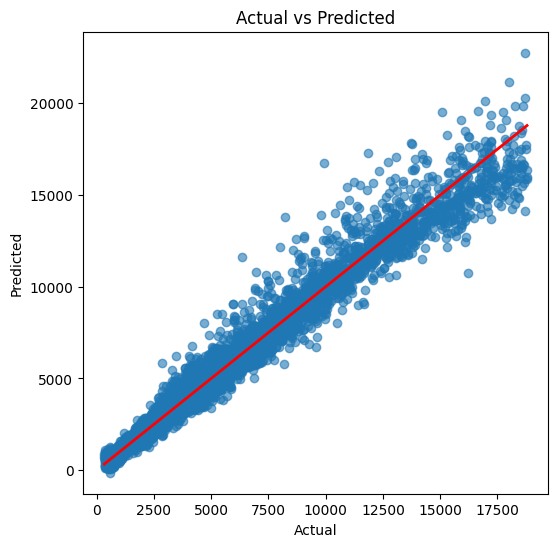

In [16]:
sample = 10000
plt.figure(figsize=(6,6))

plt.scatter(y_test[:sample],
    y_hat[:sample],
    alpha= 0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.show()